In [1]:
!pip install tf-levenberg-marquardt 

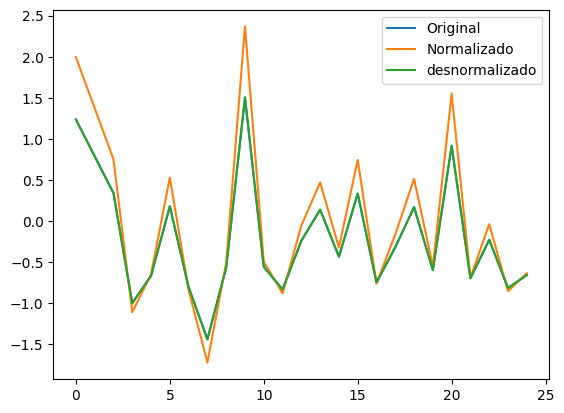

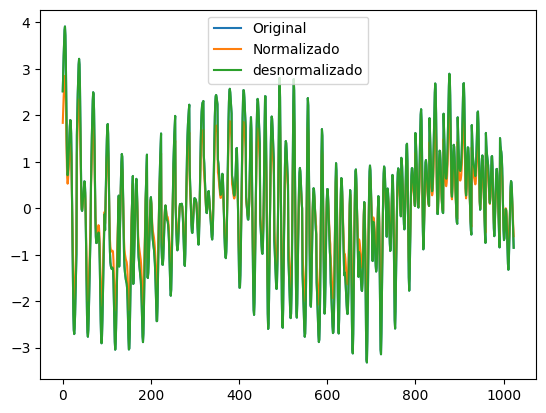

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def peaks(grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    return x, y, z

def create_dataframe_(filepaths, grid):
    x, y, z = peaks(grid)
    z_pred_total = np.zeros_like(z).ravel()
    for filepath in filepaths:
        z_pred = pd.read_excel(filepath, usecols=['Z_pred']).squeeze('columns').to_numpy()
        z_pred_total += z_pred
    z_residuo= z.flatten() - (z_pred_total)
    data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z_residuo}
    df = pd.DataFrame(data)
    return df
 
def create_dataframe(grid):
   x, y, z = peaks(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()

arquivos_25 = [
    "25_model_13_2_14.xlsx",
    "25_model_12_6_0.xlsx",
    "25_model_33_7_2.xlsx",
    "25_model_29_7_11.xlsx",
    "25_model_23_6_4.xlsx"

]
arquivos_1000 = [
    "1000_model_13_2_14.xlsx",
    "1000_model_12_6_0.xlsx",
    "1000_model_33_7_2.xlsx",
    "1000_model_29_7_11.xlsx",
    "1000_model_23_6_4.xlsx"
]
df_25 = create_dataframe_(arquivos_25, grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe_(arquivos_1000,grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-11-06 16:28:39.407461: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-06 16:28:39.440911: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-06 16:28:39.440944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-06 16:28:39.442141: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-06 16:28:39.448211: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-06 16:28:39.449005: I tensorflow/core/platform/cpu_feature_guard.cc:1

2025-11-06 16:28:40.791413: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] >= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)
 
  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='r2',
            boundarie = 0.7,
            hidden_sizes = [[3], [4], [5], [6], [7], [8], [9], [11]],
            regularizers=[0.2, 0.05],
            learning_rate=[0.01, 0.1]) 

Testando combinacao1: Hidden Size=[3], regularizer=0.2, learning_rate=0.01
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  13
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  11
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  10
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  12
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_3_3_0,0.701311,-0.211749,-22.203936,0.813080,0.433758,0.568313,2.305585,1.014555,0.322086,0.668321,0.859973,0.753866,0.348315,0.785959,27.130165,42.975551
model_3_3_1,0.702360,-0.213787,-22.696250,0.812551,0.424253,0.566317,2.309461,1.036081,0.322997,0.679539,0.858539,0.752540,0.350604,0.784578,27.137202,42.982588
model_3_3_2,0.703254,-0.216228,-23.195644,0.811495,0.414232,0.564616,2.314106,1.057916,0.324817,0.691367,0.857386,0.751409,0.352554,0.783399,27.143218,42.988604
model_3_3_3,0.703976,-0.219093,-23.706426,0.809908,0.403612,0.563241,2.319557,1.080249,0.327552,0.703900,0.856520,0.750494,0.354130,0.782444,27.148094,42.993479
model_3_3_4,0.704488,-0.222464,-24.237433,0.807747,0.392200,0.562267,2.325971,1.103467,0.331275,0.717371,0.856013,0.749845,0.355247,0.781767,27.151556,42.996941
model_3_3_5,0.704749,-0.226419,-24.799142,0.804996,0.379787,0.561772,2.333498,1.128026,0.336016,0.732021,0.855914,0.749515,0.355815,0.781423,27.153318,42.998704
model_3_3_6,0.704697,-0.231080,-25.406993,0.801628,0.366070,0.561871,2.342366,1.154604,0.341818,0.748211,0.856299,0.749581,0.355702,0.781492,27.152965,42.998350
model_3_3_7,0.704270,-0.236558,-26.078291,0.797658,0.350738,0.562682,2.352788,1.183955,0.348659,0.766307,0.857207,0.750121,0.354772,0.782056,27.150081,42.995467
model_3_3_8,0.703384,-0.243023,-26.836878,0.793101,0.333360,0.564368,2.365089,1.217123,0.356512,0.786817,0.858700,0.751244,0.352839,0.783226,27.144098,42.989484
model_3_3_9,0.701931,-0.250702,-27.713383,0.787987,0.313392,0.567134,2.379700,1.255447,0.365323,0.810385,0.860840,0.753083,0.349667,0.785143,27.134320,42.979706


DataFrame salvo em content/results/metrics_3_3
+++++++++++ [3_4] | 1 ++++++++++++++++++
Stopped at epoch:  16
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 3 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 4 ++++++++++++++++++
Stopped at epoch:  11
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 5 ++++++++++++++++++
Stopped at epoch:  12
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 9 ++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_7_0_0,0.700206,-0.316514,-0.402557,-8.119577,-1.227588,0.570415,2.504921,1.436099,1.133031,1.284565,0.820817,0.755258,-0.027865,0.787411,35.122781,55.84367


DataFrame salvo em content/results/metrics_7_0
+++++++++++ [7_1] | 1 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [7_1] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [7_1] | 3 ++++++++++++++++++
Stopped at epoch:  18
32/32 [==============================] - 0s 2ms/step
+++++++++++ [7_1] | 4 ++++++++++++++++++
Stopped at epoch:  24
32/32 [==============================] - 0s 2ms/step
+++++++++++ [7_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [7_1] | 6 ++++++++++++++++++
Stopped at epoch:  10
32/32 [==============================] - 0s 2ms/step
+++++++++++ [7_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [7_1] | 8 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [7_1] | 9 ++++++++

...

DataFrame salvo em content/results/metrics_32_7
+++++++++++ [32_8] | 1 ++++++++++++++++++
Stopped at epoch:  94
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 2 ++++++++++++++++++
Stopped at epoch:  12
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 4 ++++++++++++++++++
Stopped at epoch:  16
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_32_8_12,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413
model_32_8_22,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413
model_32_8_21,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413
model_32_8_20,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413
model_32_8_19,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413
model_32_8_18,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413
model_32_8_17,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413
model_32_8_16,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413
model_32_8_15,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413
model_32_8_14,0.977229,-0.337694,0.960403,0.680317,0.925212,0.043326,2.545218,0.121850,0.148938,0.135394,0.105023,0.208149,1.026024,0.217011,96.278001,151.127413


DataFrame salvo em content/results/metrics_32_8
+++++++++++ [32_9] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 2 ++++++++++++++++++
Stopped at epoch:  106
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 3 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 4 ++++++++++++++++++
Stopped at epoch:  12
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_32_9_3,0.974251,-0.309014,0.944618,0.890777,0.949120,0.048993,2.490650,0.112933,0.193271,0.153102,0.127699,0.221343,1.029428,0.230766,96.032167,150.881579
model_32_9_4,0.974251,-0.309014,0.944618,0.890777,0.949120,0.048993,2.490650,0.112933,0.193271,0.153102,0.127699,0.221343,1.029428,0.230766,96.032166,150.881578
model_32_9_12,0.974251,-0.309014,0.944617,0.890777,0.949120,0.048993,2.490650,0.112935,0.193272,0.153104,0.127699,0.221344,1.029428,0.230767,96.032152,150.881564
model_32_9_22,0.974251,-0.309014,0.944617,0.890777,0.949120,0.048993,2.490650,0.112935,0.193272,0.153104,0.127699,0.221344,1.029428,0.230767,96.032152,150.881564
model_32_9_21,0.974251,-0.309014,0.944617,0.890777,0.949120,0.048993,2.490650,0.112935,0.193272,0.153104,0.127699,0.221344,1.029428,0.230767,96.032152,150.881564
model_32_9_20,0.974251,-0.309014,0.944617,0.890777,0.949120,0.048993,2.490650,0.112935,0.193272,0.153104,0.127699,0.221344,1.029428,0.230767,96.032152,150.881564
model_32_9_19,0.974251,-0.309014,0.944617,0.890777,0.949120,0.048993,2.490650,0.112935,0.193272,0.153104,0.127699,0.221344,1.029428,0.230767,96.032152,150.881564
model_32_9_18,0.974251,-0.309014,0.944617,0.890777,0.949120,0.048993,2.490650,0.112935,0.193272,0.153104,0.127699,0.221344,1.029428,0.230767,96.032152,150.881564
model_32_9_17,0.974251,-0.309014,0.944617,0.890777,0.949120,0.048993,2.490650,0.112935,0.193272,0.153104,0.127699,0.221344,1.029428,0.230767,96.032152,150.881564
model_32_9_16,0.974251,-0.309014,0.944617,0.890777,0.949120,0.048993,2.490650,0.112935,0.193272,0.153104,0.127699,0.221344,1.029428,0.230767,96.032152,150.881564


DataFrame salvo em content/results/metrics_32_9
